# Завдання 2. Оцінка A/B тесту частоти імейлів

Розрахунок строго за протоколом: `hypotheses/t2-ab-test.md`, розділ 8 (записаний до розрахунку).

**Що порівнюємо:** група b отримує імейли вдвічі частіше, ніж група a. Ефект — зміна метрики в b порівняно з a, %.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path
from scipy import stats
from scipy.optimize import brentq

ROOT = Path.cwd()
DATA, SQL, FIG = ROOT / "data", ROOT / "sql", ROOT / "figures"
FIG.mkdir(exist_ok=True)

N_BOOT = 2000
CAP_Q = 0.999
WEIGHTS = {"revenue": 0.5, "payer": 0.2, "active_days": 0.3}
METRICS = ["revenue", "payer", "active_days", "episodes"]
LOOKS = pd.to_datetime(["2022-08-08", "2022-08-15", "2022-08-22", "2022-08-25"])

COLORS = {"a": "#eb6834", "b": "#2a78d6"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#52514e", "axes.labelcolor": "#0b0b0b", "text.color": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "axes.grid": True,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "lines.linewidth": 2, "font.size": 10,
})
pd.options.display.float_format = "{:,.2f}".format

## 1. Таблиці метрик (SQL) і звірка з сирими даними
SQL-файли з `sql/` запускаються по черзі; звірка має дати нульову різницю в кожному рядку.

In [2]:
con = duckdb.connect()
con.execute(f"set file_search_path = '{DATA.as_posix()}'")
for f in sorted(SQL.glob("0*.sql")):
    con.execute(f.read_text(encoding="utf-8"))

checks = con.execute((SQL / "99_checks.sql").read_text(encoding="utf-8")).df()
checks["diff"] = checks.actual - checks.expected
assert (checks["diff"] == 0).all(), "звірка не зійшлась"
checks

,check_name,expected,actual,diff
0,усі користувачі розкладені по популяціях,"430,961.00","430,961.00",0.00
1,"у метриках — усі нові й старі, по одному рядку","389,515.00","389,515.00",0.00
2,виручка нових = сирі оплати у їхніх вікнах без...,"741,630.00","741,630.00",0.00
3,виручка старих у тесті = сирі оплати 01.08–25....,"1,353,510.00","1,353,510.00",0.00
4,виручка старих у базі = сирі оплати 18.07–31.07,"1,085,860.00","1,085,860.00",0.00
5,активні дні нових = сирі візити у їхніх вікнах,"512,828.00","512,828.00",0.00
6,епізоди старих у тесті = сирий лог 01.08–25.08,"1,044,529.00","1,044,529.00",0.00
7,денні нові: сума активних = сума активних днів...,"512,828.00","512,828.00",0.00
8,денні старі: виручка тесту = виручка тесту в м...,"1,353,510.00","1,353,510.00",0.00
9,проміжні старі на 25.08 = фінальна виручка старих,"1,353,510.00","1,353,510.00",0.00


In [3]:
um = con.execute("select * from user_metrics").df()
um["reg_date"] = pd.to_datetime(um.reg_date)
for c in ["payer", "payer_base"]:
    um[c] = um[c].astype(float)

um.groupby(["population", "consent", "split_group"]).size().unstack()

split_group             a      b
population consent              
new        consent  34273  34237
           control  63591  64431
old        consent  47469  20345
           control  87699  37470

## 2. Обрізання найбільших платників
Виручка вище 99,9-го перцентиля рахується на рівні порогу. Поріг спільний для a і b в межах популяції та згоди.

In [4]:
def cap(df, col):
    thr = df.groupby(["population", "consent"])[col].transform(lambda s: s.quantile(CAP_Q))
    return df[col].clip(upper=thr), thr

um["revenue_raw"] = um.revenue
um["revenue"], um["revenue_cap"] = cap(um, "revenue_raw")
old = um.population == "old"
um.loc[old, "revenue_base"], _ = cap(um[old].assign(r=um.loc[old, "revenue_base"]), "r")

(um.groupby(["population", "consent"])
   .apply(lambda g: pd.Series({
       "поріг": g.revenue_cap.iloc[0],
       "людей вище порогу": int((g.revenue_raw > g.revenue_cap).sum()),
       "зрізано виручки, %": 100 * (1 - g.revenue.sum() / g.revenue_raw.sum()),
   })))

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_44416\1495180975.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


поріг  людей вище порогу  зрізано виручки, %
population consent                                                
new        consent   360.00              59.00                1.36
           control   360.00             112.00                1.23
old        consent 1,060.00              67.00                1.14
           control 1,010.00             122.00                1.33

## 3. Оцінка ефекту
- Ефект метрики — (середнє b − середнє a) / середнє a, %.
- Старі — з CUPED: від метрики в тесті віднімається частина, передбачувана тією ж метрикою в базі 18–31.07; коефіцієнт спільний для a і b.
- Бал = 0,5 · виручка + 0,2 · платники + 0,3 · активні дні. Епізоди — лише залученість, у бал не входять.
- Інтервали — бутстреп по користувачах (пуассонівські ваги, 2000 повторів). Одні й ті самі ваги для всіх метрик, тож бал має чесний інтервал.

In [5]:
def rel_effects(df, cuped, n_boot=N_BOOT, seed=42, metrics=METRICS):
    rng = np.random.default_rng(seed)
    is_b = (df.split_group == "b").to_numpy()
    n = len(df)
    Y = {m: df[m].to_numpy(float) for m in metrics}
    X = {m: df[m + "_base"].to_numpy(float) for m in metrics} if cuped else None

    def one_batch(W):
        out = {}
        wb, wa, sw = W[is_b].sum(0), W[~is_b].sum(0), W.sum(0)
        for m in metrics:
            y = Y[m]
            yb, ya = y[is_b] @ W[is_b] / wb, y[~is_b] @ W[~is_b] / wa
            if cuped:
                x = X[m]
                mx, my = x @ W / sw, y @ W / sw
                theta = ((x * y) @ W / sw - mx * my) / ((x * x) @ W / sw - mx ** 2)
                xb, xa = x[is_b] @ W[is_b] / wb, x[~is_b] @ W[~is_b] / wa
                yb, ya = yb - theta * (xb - mx), ya - theta * (xa - mx)
            out[m] = 100 * (yb / ya - 1)
        out["score"] = sum(WEIGHTS[m] * out[m] for m in WEIGHTS)
        return out

    point = {k: v[0] for k, v in one_batch(np.ones((n, 1))).items()}
    batches = [one_batch(rng.poisson(1, (n, 100)).astype(np.float32)) for _ in range(n_boot // 100)]
    draws = pd.DataFrame({k: np.concatenate([b[k] for b in batches]) for k in point})
    return pd.Series(point), draws


def summarize(point, draws):
    lo, hi = draws.quantile(0.025), draws.quantile(0.975)
    p = 2 * np.minimum((draws <= 0).mean(), (draws >= 0).mean()).clip(upper=0.5)
    return pd.DataFrame({"ефект, %": point, "95% від": lo, "95% до": hi,
                         "похибка": draws.std(), "p": p})


SLICES = {
    ("new", "consent"): False, ("old", "consent"): True,
    ("new", "control"): False, ("old", "control"): True,
}
est = {}
for (pop, consent), cuped in SLICES.items():
    df = um[(um.population == pop) & (um.consent == consent)]
    est[(pop, consent)] = rel_effects(df, cuped) + (len(df),)

In [6]:
def combine(consent):
    (p_new, d_new, n_new), (p_old, d_old, n_old) = est[("new", consent)], est[("old", consent)]
    w_new, w_old = n_new / (n_new + n_old), n_old / (n_new + n_old)
    return w_new * p_new["score"] + w_old * p_old["score"], w_new * d_new["score"] + w_old * d_old["score"]

rows = []
for consent in ["consent", "control"]:
    for pop in ["new", "old"]:
        point, draws, n = est[(pop, consent)]
        s = summarize(point, draws)
        s.insert(0, "людей", n)
        rows.append(s.assign(consent=consent, population=pop))
    tp, td = combine(consent)
    s = summarize(pd.Series({"score": tp}), td.to_frame("score"))
    rows.append(s.assign(consent=consent, population="total"))

effects = (pd.concat(rows).rename_axis("metric").reset_index()
             .set_index(["consent", "population", "metric"]))
effects

людей  ефект, %  95% від  95% до  похибка  \
consent population metric                                                       
consent new        revenue      68,510.00      6.04    -3.30   16.80     5.06   
                   payer        68,510.00      2.52    -4.00    9.37     3.41   
                   active_days  68,510.00      6.48     5.76    7.16     0.36   
                   episodes     68,510.00      6.24     4.45    8.03     0.92   
                   score        68,510.00      5.47    -0.27   11.93     3.11   
        old        revenue      67,814.00     -7.12   -12.07   -1.84     2.59   
                   payer        67,814.00      1.02    -1.39    3.43     1.23   
                   active_days  67,814.00     -3.26    -6.02   -0.29     1.47   
                   episodes     67,814.00    -12.33   -15.72   -8.70     1.79   
                   score        67,814.00     -4.34    -7.33   -1.10     1.57   
        total      score              NaN      0.59    -2.69    4.20     1.77   
control new        revenue     128,022.00     -1.37    -8.09    6.02     3.59   
                   payer       128,022.00      1.89    -3.17    6.76     2.56   
                   active_days 128,022.00      0.29    -0.30    0.87     0.29   
                   episodes    128,022.00      0.33    -1.03    1.75     0.72   
                   score       128,022.00     -0.22    -4.35    4.25     2.21   
        old        revenue     125,169.00     -0.10    -4.20    4.19     2.16   
                   payer       125,169.00     -0.97    -3.73    1.75     1.39   
                   active_days 125,169.00      1.45    -1.84    4.80     1.69   
                   episodes    125,169.00     -0.84    -4.54    2.92     1.89   
                   score       125,169.00      0.19    -2.57    3.09     1.46   
        total      score              NaN     -0.02    -2.59    2.65     1.32   

                                  p  
consent population metric            
consent new        revenue     0.23  
                   payer       0.45  
                   active_days 0.00  
                   episodes    0.00  
                   score       0.06  
        old        revenue     0.01  
                   payer       0.42  
                   active_days 0.03  
                   episodes    0.00  
                   score       0.01  
        total      score       0.73  
control new        revenue     0.71  
                   payer       0.45  
                   active_days 0.31  
                   episodes    0.65  
                   score       0.92  
        old        revenue     0.95  
                   payer       0.51  
                   active_days 0.38  
                   episodes    0.67  
                   score       0.90  
        total      score       0.98

## 4. Перевірки довіри
- **Контроль:** у користувачів без згоди на листи бал має бути ≈ 0 (95% інтервал містить 0).
- **Протилежні ефекти:** бали нових і старих мають різний знак, і обидва інтервали не містять 0.

In [7]:
def ci_contains_zero(consent, pop, metric="score"):
    r = effects.loc[(consent, pop, metric)]
    return r["95% від"] <= 0 <= r["95% до"]

control_ok = {pop: ci_contains_zero("control", pop) for pop in ["new", "old", "total"]}

s_new, s_old = effects.loc[("consent", "new", "score")], effects.loc[("consent", "old", "score")]
opposite = (np.sign(s_new["ефект, %"]) != np.sign(s_old["ефект, %"])
            and not ci_contains_zero("consent", "new") and not ci_contains_zero("consent", "old"))

pd.Series({"контроль нових: інтервал містить 0": control_ok["new"],
           "контроль старих: інтервал містить 0": control_ok["old"],
           "контроль разом: інтервал містить 0": control_ok["total"],
           "ефекти нових і старих протилежні": opposite})

контроль нових: інтервал містить 0      True
контроль старих: інтервал містить 0     True
контроль разом: інтервал містить 0      True
ефекти нових і старих протилежні       False
dtype: bool

## 5. Рекомендація за правилом протоколу (8.5)

In [8]:
def recommend():
    if not all(control_ok.values()):
        return "контроль показав ефект — результат не інтерпретуємо, доки не знайдено причину"
    veto = [pop for pop in ["new", "old"] if effects.loc[("consent", pop, "active_days"), "95% до"] < 0]
    if opposite:
        return "ефекти нових і старих протилежні — окремі рекомендації для кожної популяції"
    total = effects.loc[("consent", "total", "score")]
    if veto:
        return f"заборона: активні дні знизились ({', '.join(veto)}) — не надсилати частіше цій популяції"
    if total["95% від"] > 0:
        return "надсилати імейли частіше всім"
    if total["95% до"] < 0:
        return "не надсилати частіше"
    return "ефекту не видно — порівняти з мінімальним помітним ефектом"

recommend()

'заборона: активні дні знизились (old) — не надсилати частіше цій популяції'

## 6. Графік ефектів

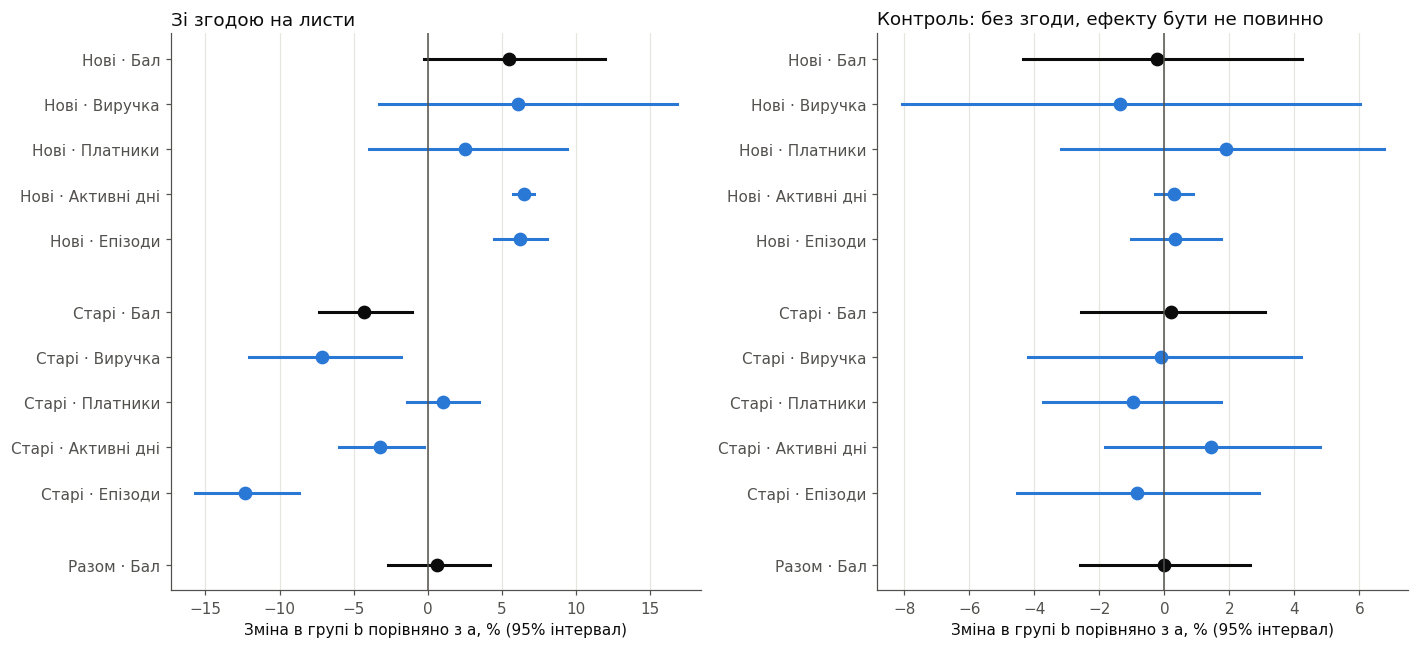

In [9]:
def forest(ax, consent, title):
    labels = {"revenue": "Виручка", "payer": "Платники", "active_days": "Активні дні",
              "episodes": "Епізоди", "score": "Бал"}
    pops = {"new": "Нові", "old": "Старі", "total": "Разом"}
    y, ticks = 0, []
    for pop in ["new", "old", "total"]:
        for m in ["score", "revenue", "payer", "active_days", "episodes"]:
            if (consent, pop, m) not in effects.index:
                continue
            r = effects.loc[(consent, pop, m)]
            color = "#0b0b0b" if m == "score" else "#2a78d6"
            ax.plot([r["95% від"], r["95% до"]], [y, y], color=color, lw=2)
            ax.plot(r["ефект, %"], y, "o", color=color, ms=8)
            ticks.append((y, f"{pops[pop]} · {labels[m]}"))
            y -= 1
        y -= 0.6
    ax.axvline(0, color="#52514e", lw=1)
    ax.set_yticks([t[0] for t in ticks], [t[1] for t in ticks])
    ax.set_xlabel("Зміна в групі b порівняно з a, % (95% інтервал)")
    ax.set_title(title, loc="left")
    ax.grid(axis="y", visible=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=False)
forest(axes[0], "consent", "Зі згодою на листи")
forest(axes[1], "control", "Контроль: без згоди, ефекту бути не повинно")
fig.tight_layout()
fig.savefig(FIG / "effects.png", bbox_inches="tight")

## 7. Когортна динаміка
**Нові:** частка тих, хто зайшов у день N після реєстрації, і накопичена виручка на користувача (зі згодою на листи). Криві описові, без інтервалів.

day_n                     0     1     2     3     4     5     6
reg_week split_group                                           
01–07.08 a           100.00 51.63 38.19 30.86 26.69 21.89 19.73
         b           100.00 58.19 41.39 34.08 28.39 25.46 22.28
08–14.08 a           100.00 53.15 37.58 29.97 27.18 22.96 19.80
         b           100.00 58.25 42.57 34.06 28.58 23.87 21.58
15–19.08 a           100.00 51.90 38.06 30.73 26.02 23.60 20.49
         b           100.00 58.01 42.02 33.83 28.04 24.37 21.84

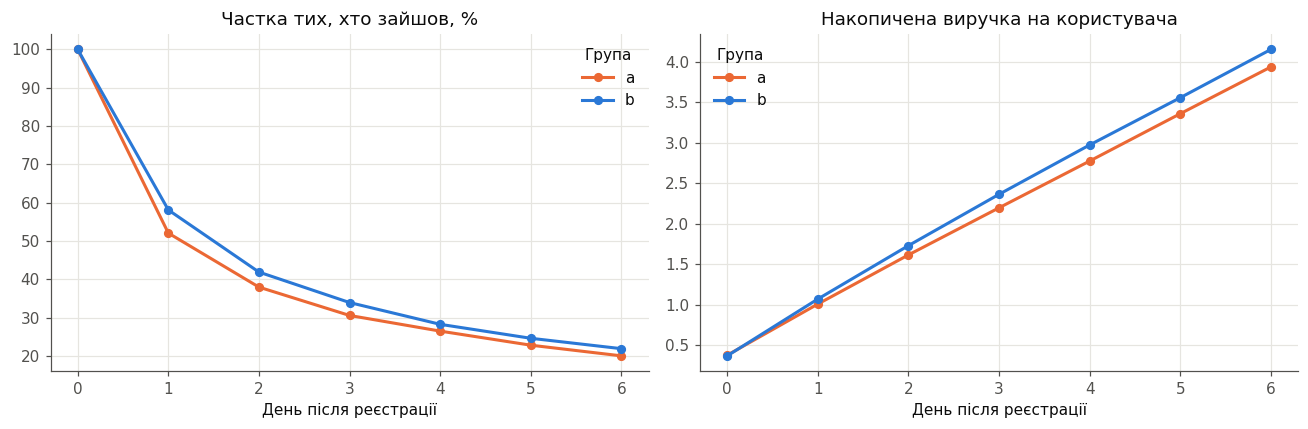

In [10]:
dn = con.execute("select * from daily_new where consent = 'consent'").df()
agg = dn.groupby(["split_group", "day_n"])[["users", "active_users", "revenue"]].sum().reset_index()
agg["active_share"] = 100 * agg.active_users / agg.users
agg["cum_revenue"] = agg.groupby("split_group").revenue.cumsum() / agg.users

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for g, d in agg.groupby("split_group"):
    axes[0].plot(d.day_n, d.active_share, marker="o", ms=5, color=COLORS[g], label=g)
    axes[1].plot(d.day_n, d.cum_revenue, marker="o", ms=5, color=COLORS[g], label=g)
axes[0].set(title="Частка тих, хто зайшов, %", xlabel="День після реєстрації")
axes[1].set(title="Накопичена виручка на користувача", xlabel="День після реєстрації")
for ax in axes:
    ax.legend(title="Група", frameon=False)
fig.tight_layout()
fig.savefig(FIG / "cohort_new.png", bbox_inches="tight")

pivot = (dn.groupby(["reg_week", "split_group", "day_n"])[["users", "active_users"]].sum()
           .assign(share=lambda d: 100 * d.active_users / d.users).share.unstack("day_n"))
pivot

**Нові по тижнях реєстрації:** бал і ефекти з інтервалами; p з поправкою Голма на три когорти.

In [11]:
def holm(p):
    order = np.argsort(p.values)
    adj = np.empty(len(p))
    running = 0
    for rank, i in enumerate(order):
        running = max(running, (len(p) - rank) * p.values[i])
        adj[i] = min(running, 1)
    return pd.Series(adj, index=p.index)

def by_group(pop, col, cuped):
    rows = {}
    base = um[(um.population == pop) & (um.consent == "consent")]
    for key, df in base.groupby(col):
        point, draws = rel_effects(df, cuped, seed=7)
        rows[key] = summarize(point, draws).loc["score"]
    out = pd.DataFrame(rows).T
    out["p Голм"] = holm(out["p"])
    return out

by_group("new", "reg_week", cuped=False)

,"ефект, %",95% від,95% до,похибка,p,p Голм
01–07.08,7.38,-1.50,18.50,5.20,0.12,0.35
08–14.08,-2.20,-13.08,11.21,6.18,0.75,0.75
15–19.08,7.25,-2.33,17.90,4.96,0.14,0.35


**Старі:** частка активних і виручка на користувача за кожен день, відносно середнього дня бази 18–31.07 своєї групи (= 100). 14–15.08 у виручці пропущено — оплат у даних нема.

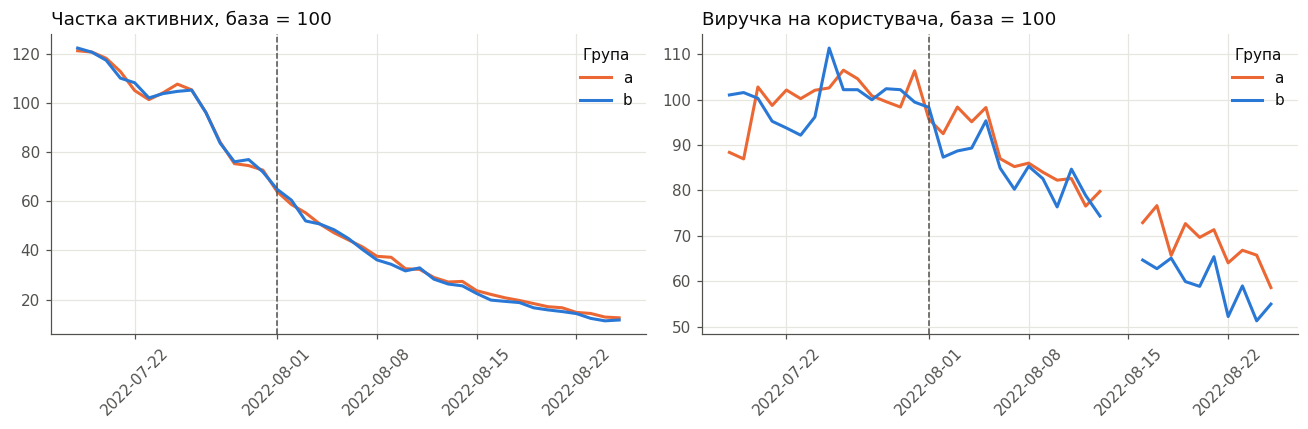

In [12]:
do = con.execute("select * from daily_old where consent = 'consent'").df()
do["date"] = pd.to_datetime(do.date)
do["active_share"] = do.active_users / do.users
do["rev_per_user"] = do.revenue / do.users
do.loc[do.missing_revenue, "rev_per_user"] = np.nan
base = do[~do.is_test].groupby("split_group")[["active_share", "rev_per_user"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for g, d in do.sort_values("date").groupby("split_group"):
    for ax, col, title in [(axes[0], "active_share", "Частка активних, база = 100"),
                           (axes[1], "rev_per_user", "Виручка на користувача, база = 100")]:
        ax.plot(d.date, 100 * d[col] / base.loc[g, col], color=COLORS[g], label=g)
        ax.set_title(title, loc="left")
for ax in axes:
    ax.axvline(pd.Timestamp("2022-08-01"), color="#52514e", lw=1, ls="--")
    ax.legend(title="Група", frameon=False)
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIG / "daily_old.png", bbox_inches="tight")

## 8. Розрізи країна × ОС (описово, з поправкою Голма)

In [13]:
seg = pd.concat({"new": by_group("new", "segment", cuped=False),
                 "old": by_group("old", "segment", cuped=True)})
seg["p Голм (8 розрізів)"] = holm(seg["p"])
seg

ефект, %  95% від  95% до  похибка    p  p Голм  \
new country 1 / android     21.67     0.67   50.57    12.48 0.04    0.15   
    country 2 / android      9.53    -0.58   21.38     5.53 0.06    0.19   
    country 2 / ios          2.24    -6.89   12.72     5.17 0.66    1.00   
    country 3 / desktop     -2.15   -12.71   10.58     5.89 0.72    1.00   
old country 1 / android      4.66    -9.31   22.46     7.91 0.53    1.00   
    country 2 / android     -3.35   -10.29    4.47     3.80 0.40    1.00   
    country 2 / ios         -8.19   -12.42   -3.36     2.30 0.00    0.00   
    country 3 / desktop     -1.02    -5.86    4.17     2.51 0.69    1.00   

                         p Голм (8 розрізів)  
new country 1 / android                 0.27  
    country 2 / android                 0.38  
    country 2 / ios                     1.00  
    country 3 / desktop                 1.00  
old country 1 / android                 1.00  
    country 2 / android                 1.00  
    country 2 / ios                     0.00  
    country 3 / desktop                 1.00

## 9. Додаткові питання

### 9.1 Чи достатньо даних
Мінімальний помітний ефект = 2,8 × похибка (α = 0,05, потужність 80%). Якщо отриманий ефект менший за нього, тест не мав шансу його надійно побачити.

In [14]:
mde = effects.loc["consent"].assign(**{"мін. помітний ефект, %": lambda d: 2.8 * d["похибка"]})
mde[["ефект, %", "95% від", "95% до", "мін. помітний ефект, %"]]

ефект, %  95% від  95% до  мін. помітний ефект, %
population metric                                                        
new        revenue          6.04    -3.30   16.80                   14.18
           payer            2.52    -4.00    9.37                    9.56
           active_days      6.48     5.76    7.16                    1.02
           episodes         6.24     4.45    8.03                    2.58
           score            5.47    -0.27   11.93                    8.70
old        revenue         -7.12   -12.07   -1.84                    7.27
           payer            1.02    -1.39    3.43                    3.44
           active_days     -3.26    -6.02   -0.29                    4.12
           episodes       -12.33   -15.72   -8.70                    5.01
           score           -4.34    -7.33   -1.10                    4.39
total      score            0.59    -2.69    4.20                    4.94

### 9.2 Чи можна було закрити тест раніше
Загальний бал на даних, доступних на 08.08, 15.08, 22.08 і 25.08. Межі О'Браєна–Флемінга (витрачання α за Lan–DeMets, частка інформації = (похибка на 25.08 / похибка на дату)²).

In [15]:
io = con.execute("select * from interim_old where consent = 'consent'").df()
io["look_date"] = pd.to_datetime(io.look_date)
base_old = um[(um.population == "old") & (um.consent == "consent")].set_index("id")

def at_look(look):
    new = um[(um.population == "new") & (um.consent == "consent") & (um.reg_date <= look - pd.Timedelta(days=6))]
    o = io[io.look_date == look].set_index("id").join(base_old[[c for c in base_old if c.endswith("_base")]])
    o["payer"] = (o.revenue > 0).astype(float)
    o["revenue"] = o.revenue.clip(upper=o.revenue.quantile(CAP_Q))
    score_metrics = list(WEIGHTS)
    p_n, d_n = rel_effects(new, cuped=False, n_boot=1000, metrics=score_metrics)
    p_o, d_o = rel_effects(o.reset_index(), cuped=True, n_boot=1000, metrics=score_metrics)
    w = len(new) / (len(new) + len(o))
    return w * p_n["score"] + (1 - w) * p_o["score"], (w * d_n["score"] + (1 - w) * d_o["score"]).std(), len(new), len(o)

seq = pd.DataFrame([dict(zip(["бал, %", "похибка", "нових", "старих"], at_look(l))) for l in LOOKS], index=LOOKS.date)
seq["z"] = seq["бал, %"] / seq["похибка"]
seq["частка інформації"] = (seq["похибка"].iloc[-1] / seq["похибка"]) ** 2


def obf_bounds(t, alpha=0.05):
    spend = lambda s: 2 - 2 * stats.norm.cdf(stats.norm.ppf(1 - alpha / 2) / np.sqrt(s))
    bounds = []
    for k in range(len(t)):
        tt = t[: k + 1]
        cov = np.sqrt(np.minimum.outer(tt, tt) / np.maximum.outer(tt, tt))
        mvn = stats.multivariate_normal(mean=np.zeros(k + 1), cov=cov)
        f = lambda x: 1 - mvn.cdf(np.array(bounds + [x]), lower_limit=-np.array(bounds + [x])) - spend(tt[-1])
        bounds.append(brentq(f, 0.5, 15))
    return np.array(bounds)

seq["межа |z|"] = obf_bounds(np.maximum.accumulate(seq["частка інформації"].clip(upper=1).values))
seq["перетнуто"] = seq.z.abs() >= seq["межа |z|"]
seq

,"бал, %",похибка,нових,старих,z,частка інформації,межа |z|,перетнуто
2022-08-08,-0.39,2.02,3389,67814,-0.19,0.71,2.32,False
2022-08-15,0.97,1.88,25562,67814,0.52,0.83,2.25,False
2022-08-22,-0.44,1.72,49325,67814,-0.26,0.98,2.09,False
2022-08-25,0.59,1.71,68510,67814,0.35,1.00,2.15,False


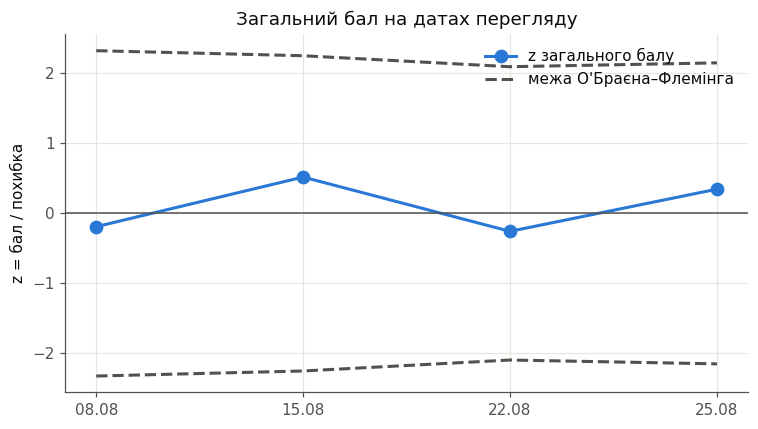

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(seq))
ax.plot(x, seq.z, marker="o", ms=8, color="#2a78d6", label="z загального балу")
ax.plot(x, seq["межа |z|"], ls="--", color="#52514e", label="межа О'Браєна–Флемінга")
ax.plot(x, -seq["межа |z|"], ls="--", color="#52514e")
ax.axhline(0, color="#52514e", lw=1)
ax.set_xticks(x, [d.strftime("%d.%m") for d in LOOKS])
ax.set(title="Загальний бал на датах перегляду", ylabel="z = бал / похибка")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG / "sequential.png", bbox_inches="tight")

### 9.3 Чи варто застосувати CUPED
- **Старі:** похибка з CUPED і без; зменшення дисперсії = 1 − (похибка з CUPED / без)².
- **Нові:** даних до тесту нема; альтернатива — коригування за розрізом країна × ОС (регресія), та сама міра.

In [17]:
old_c = um[(um.population == "old") & (um.consent == "consent")]
p_raw, d_raw = rel_effects(old_c, cuped=False)
se_cuped, se_raw = est[("old", "consent")][1].std(), d_raw.std()
cuped_old = pd.DataFrame({"похибка без CUPED": se_raw, "похибка з CUPED": se_cuped,
                          "ефект без CUPED, %": p_raw, "ефект з CUPED, %": est[("old", "consent")][0]})
cuped_old["зменшення дисперсії, %"] = 100 * (1 - (cuped_old["похибка з CUPED"] / cuped_old["похибка без CUPED"]) ** 2)

new_c = um[(um.population == "new") & (um.consent == "consent")].assign(is_b=lambda d: (d.split_group == "b").astype(int))
adj = {}
for m in ["revenue", "payer", "active_days"]:
    se0 = smf.ols(f"{m} ~ is_b", new_c).fit(cov_type="HC1").bse["is_b"]
    se1 = smf.ols(f"{m} ~ is_b + C(segment)", new_c).fit(cov_type="HC1").bse["is_b"]
    adj[m] = 100 * (1 - (se1 / se0) ** 2)

display(cuped_old)
pd.Series(adj, name="нові: зменшення дисперсії від розрізу країна × ОС, %")

,похибка без CUPED,похибка з CUPED,"ефект без CUPED, %","ефект з CUPED, %","зменшення дисперсії, %"
revenue,7.57,2.59,6.88,-7.12,88.24
payer,4.08,1.23,6.85,1.02,90.94
active_days,1.89,1.47,-1.58,-3.26,39.18
episodes,4.19,1.79,-4.57,-12.33,81.77
score,4.73,1.57,4.34,-4.34,89.04


revenue        0.04
payer         -0.04
active_days   25.46
Name: нові: зменшення дисперсії від розрізу країна × ОС, %, dtype: float64

### 9.4 Які дані допомогли б оцінити тест швидше
Описова відповідь — у висновках після перегляду результатів.

## 10. Висновки
Заповнюються після спільного перегляду результатів.